In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 1 Data Familiarization and Clearning
df=pd.read_csv('netflix_titles.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       6234 non-null   int64
 1   type          6234 non-null   str  
 2   title         6234 non-null   str  
 3   director      4265 non-null   str  
 4   cast          5664 non-null   str  
 5   country       5758 non-null   str  
 6   date_added    6223 non-null   str  
 7   release_year  6234 non-null   int64
 8   rating        6224 non-null   str  
 9   duration      6234 non-null   str  
 10  listed_in     6234 non-null   str  
 11  description   6234 non-null   str  
dtypes: int64(2), str(10)
memory usage: 584.6 KB


In [7]:
df.isna().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

In [8]:
df.dropna(subset=["date_added"],inplace=True)


In [9]:
df.isna().sum()

show_id            0
type               0
title              0
director        1958
cast             569
country          474
date_added         0
release_year       0
rating             9
duration           0
listed_in          0
description        0
dtype: int64

In [10]:
df[['director','cast']]=df[['director','cast']].fillna({
    'director':'Unknown',
    'cast':'No information'
})
df.isna().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         474
date_added        0
release_year      0
rating            9
duration          0
listed_in         0
description       0
dtype: int64

In [11]:
mode_value=df['country'].mode()[0]
df['country']= df['country'].fillna(mode_value)
# if you want the llm must provide the right answer in any situation then you should use unknown

In [12]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          9
duration        0
listed_in       0
description     0
dtype: int64

In [13]:
mode_value=df['rating'].mode()[0]
df['rating']=df['rating'].fillna(mode_value)

In [14]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [15]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [16]:
# imputer = IterativeImputer(max_iter=10, random_state=42)
# df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
# print(df_imputed)
# if I got extra time I will do this

In [17]:
# parse and clean columns
# using single \ it can be fall into special charactor
# use \\ or use r 
# using r means row data that is safest and good practice
df['duration'].str.extract(r'(\d+)')


,0
0,90
1,94
2,1
3,1
4,99
...,...
6218,2
6219,2
6220,2
6221,2


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [19]:
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(),errors='coerce')


In [20]:
print(df["date_added"].dtype)

datetime64[us]


In [21]:
from datetime import datetime

In [22]:
current_year = datetime.now().year

In [23]:
df['content_age']=current_year-df['release_year']
print(df['content_age'])

0        7
1       10
2       13
3       10
4        9
        ..
6218     9
6219     7
6220    14
6221    10
6222    14
Name: content_age, Length: 6223, dtype: int64


In [24]:
# if you want to calculate all things like the days and times 
current_date=pd.Timestamp.now()
print(current_date)

2026-06-08 08:22:26.041426


In [25]:
df['days_since_added'] = current_date - df['date_added']
df['year_since_added']=(current_date-df['date_added']).dt.days/365.25
print(df['year_since_added'])

0        6.746064
1        9.744011
2        7.748118
3        7.748118
4        8.747433
          ...    
6218     7.162218
6219     7.186858
6220    10.184805
6221    10.184805
6222    12.186174
Name: year_since_added, Length: 6223, dtype: float64


In [26]:
from sklearn.preprocessing import StandardScaler, Normalizer

In [32]:
# Section 2: Feature Engineering

df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
numeric_cols = ['duration_num', 'content_age']
X = df[numeric_cols].dropna()
print('this is df','this is dur',df['duration_num'],'this is nu col',numeric_cols,'this is drop',X)

this is df this is dur 0       90.0
1       94.0
2        1.0
3        1.0
4       99.0
        ... 
6218     2.0
6219     2.0
6220     2.0
6221     2.0
6222     8.0
Name: duration_num, Length: 6223, dtype: float64 this is nu col ['duration_num', 'content_age'] this is drop       duration_num  content_age
0             90.0            7
1             94.0           10
2              1.0           13
3              1.0           10
4             99.0            9
...            ...          ...
6218           2.0            9
6219           2.0            7
6220           2.0           14
6221           2.0           10
6222           8.0           14

[6223 rows x 2 columns]


In [33]:

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

df_standardized = pd.DataFrame(X_standardized, columns=numeric_cols)
print("Standardized Data (Mean ≈ 0, Std ≈ 1):\n", df_standardized.head())

Standardized Data (Mean ≈ 0, Std ≈ 1):
    duration_num  content_age
0      0.423587    -0.639497
1      0.502264    -0.299206
2     -1.326981     0.041085
3     -1.326981    -0.299206
4      0.600611    -0.412636


In [34]:
# Initialize the Normalizer
normalizer = Normalizer()
 
X_normalized = normalizer.fit_transform(X)

df_normalized = pd.DataFrame(X_normalized, columns=numeric_cols)
print("\nNormalized Data (Row vector length = 1):\n", df_normalized.head())


Normalized Data (Row vector length = 1):
    duration_num  content_age
0      0.996989     0.077544
1      0.994389     0.105786
2      0.076696     0.997054
3      0.099504     0.995037
4      0.995893     0.090536


In [36]:
from sklearn.preprocessing import MinMaxScaler

# Squeezes column values perfectly between 0 and 1
min_max_scaler = MinMaxScaler()
X_minmax = min_max_scaler.fit_transform(X)

df_minmax = pd.DataFrame(X_minmax, columns=numeric_cols)
print(df_minmax)

      duration_num  content_age
0         0.286174     0.010526
1         0.299035     0.042105
2         0.000000     0.073684
3         0.000000     0.042105
4         0.315113     0.031579
...            ...          ...
6218      0.003215     0.031579
6219      0.003215     0.010526
6220      0.003215     0.084211
6221      0.003215     0.042105
6222      0.022508     0.084211

[6223 rows x 2 columns]


In [37]:
#  section 3:Univariate Analysis
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_age,days_since_added,year_since_added,duration_num
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,7,2464 days 08:22:26.041426,6.746064,90.0
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,10,3559 days 08:22:26.041426,9.744011,94.0
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",13,2830 days 08:22:26.041426,7.748118,1.0
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,10,2830 days 08:22:26.041426,7.748118,1.0
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,9,3195 days 08:22:26.041426,8.747433,99.0


In [50]:
content_type=df['type'].head()
duration=df['duration'].head()
genres=df['listed_in'].head()
content_age=df['content_age'].head()
print(duration)

0      90 min
1      94 min
2    1 Season
3    1 Season
4      99 min
Name: duration, dtype: str


<Axes: xlabel='content_age', ylabel='Count'>

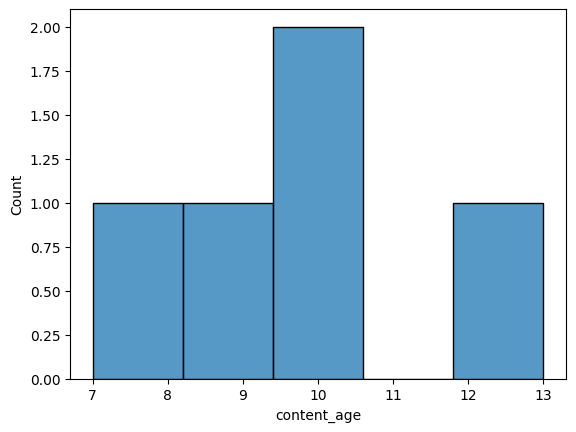

In [51]:
sns.histplot(content_age)

<Axes: xlabel='count', ylabel='duration'>

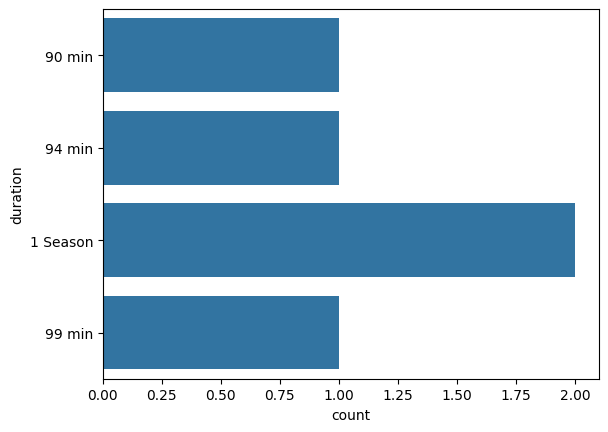

In [52]:
sns.countplot(duration)

<Axes: ylabel='listed_in'>

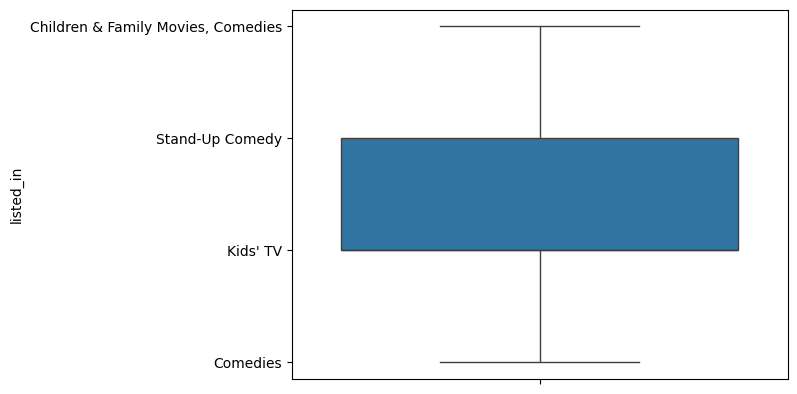

In [53]:
sns.boxplot(genres)

<Axes: ylabel='content_age'>

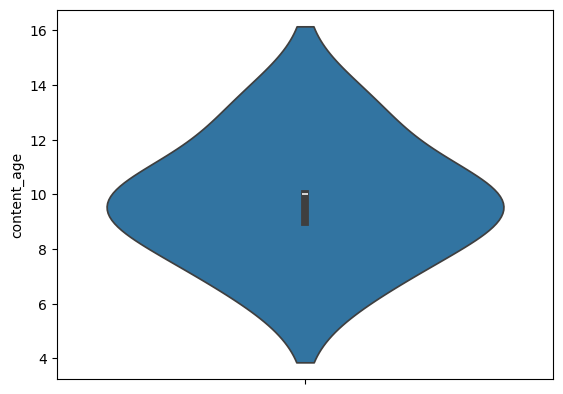

In [54]:
sns.violinplot(content_age)

In [ ]:
content_type=df['type'].head()
duration=df['duration'].head()
genres=df['listed_in'].head()
content_age=df['content_age'].head()
print(duration)
content_type.mean()